In [5]:
import gvar as gv
import numpy as np
import pickle

from cora.momenta import *
from cora.visualise import *

In [6]:
# LOAD DATA
with open('/glurch/scratch/kic04594/data/misc/C101-LHPC-RATIOS-COMPARISON.pkl', 'rb') as f:
    ratios = pickle.load(f)

In [7]:
reg_src_ids  = [0, 1, 2, 3]
lhpc_src_ids = [0, 1, 2, 3]

SOURCE ID 0
tau         REG_err       LHPC_err
   0        0.0724        0.0527
   1        0.0906        0.0513
   2        0.0786        0.0504
   3        0.0726        0.0527
   4        0.0805        0.0531
   5        0.0678        0.0543
   6        0.0536        0.0524
   7        0.0546        0.0520
   8        0.0496        0.0549
   9        0.0465        0.0529
  10        0.0647        0.0500
  11        0.0732        0.0511
  12        0.0864        0.0513
  13        0.0877        0.0533
  14        0.0930        0.0535
SOURCE ID 1
tau         REG_err       LHPC_err
   0        0.0589        0.1971
   1        0.0497        0.2143
   2        0.0502        0.1783
   3        0.0528        0.2151
   4        0.0519        0.2047
   5        0.0600        0.1643
   6        0.0573        0.1495
   7        0.0471        0.1231
   8        0.0478        0.1006
   9        0.0494        0.0848
  10        0.0581        0.0790
  11        0.0638        0.0703
  12        0.0

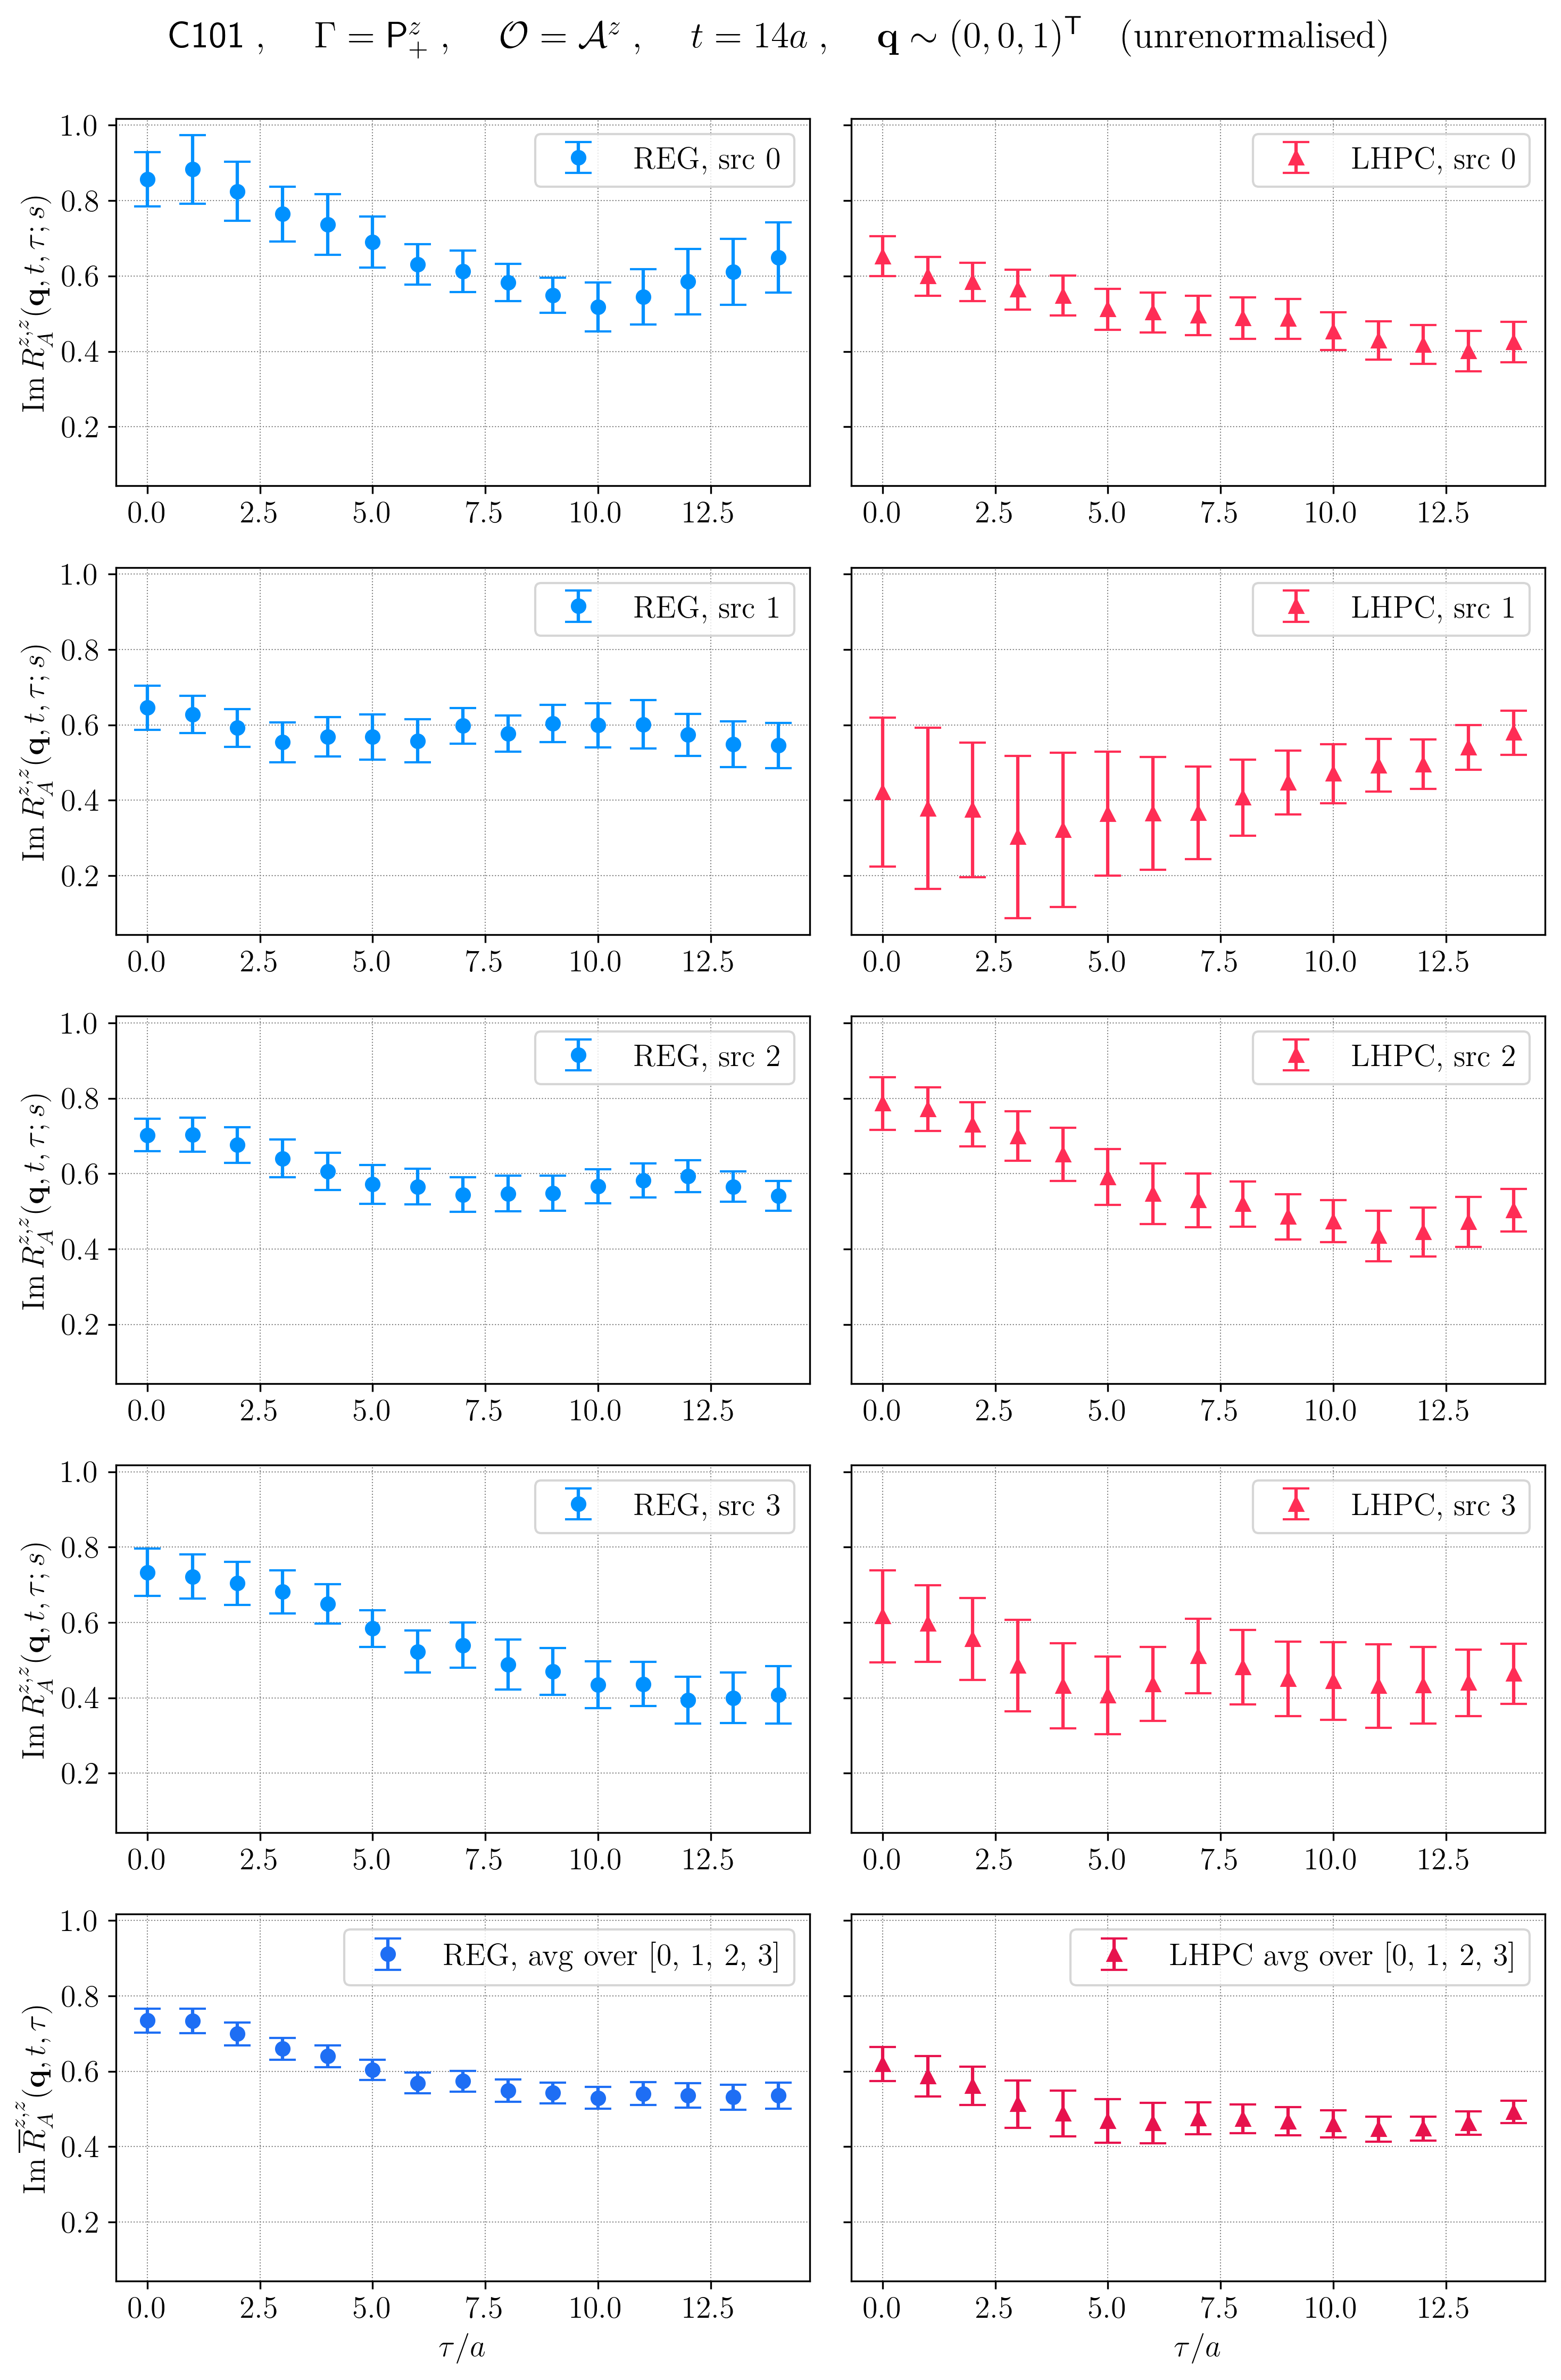

In [8]:
# momentum index qidx = 0 corresponds to (0,0,0) (forward limit)
qmax = 8
qcol: dict[str] = momentum_index_dict(qmax)
qidx = qcol['(0, 0, 1)']

fig = plot_lhpc_comparison('axial', ratios, qcol, qidx, reg_src_ids, lhpc_src_ids)
plt.show()

In [59]:
# list of excluded source ids from lhpc data
lhpc_exclude = [1,3]
reg_exclude  = [None]

# list of all source ids corresponding to lhpc data
lhpc_include = [0, 1, 2, 3]
reg_include  = [0, 1, 2, 3]

In [60]:
reg  = ratios_ax["reg"]
lhpc = ratios_ax["lhpc"]

# ids to keep in each set
reg_keep  = [i for i in reg_include  if i not in reg_exclude]
print(reg_keep)
lhpc_keep = [i for i in lhpc_include if i not in lhpc_exclude]
print(lhpc_keep)

# to combine *per source_id*, use only ids present/kept in BOTH
keep = sorted(set(reg_keep).intersection(lhpc_keep))
# with your numbers: reg_keep={1,2,3}, lhpc_keep={0,2} -> keep=[2]

# bootstrap samples of the per-source combined ratio
y_exc = 0.5 * (reg[:, keep, qidx, :] + lhpc[:, keep, qidx, :])   # (boot, n_keep, tsep)

# average over source_id (axis=1)
y_exc = y_exc.mean(axis=1)                                       # (boot, tsep)

# final estimate + bootstrap error
y_exc_est = y_exc.mean(axis=0)
y_exc_err = y_exc.std(axis=0, ddof=1)

ids = reg_include  # same as lhpc_include in your case
y_inc = 0.5 * (reg[:, ids, qidx, :] + lhpc[:, ids, qidx, :])  # (boot, 4, tsep)
y_inc = y_inc.mean(axis=1)                                    # (boot, tsep)

y_inc_est = y_inc.mean(axis=0)
y_inc_err = y_inc.std(axis=0, ddof=1)

[0, 1, 2, 3]
[0, 2]


In [61]:
print("Y-EXC")
print("est")
print(y_exc_est)
print("err")
print(y_exc_err)

print("\n")

print("Y-INC")
print("est")
print(y_inc_est)
print("err")
print(y_inc_err)

Y-EXC
est
[1.60267571 1.61765997 1.62312158 1.63642993 1.65654946 1.67275847
 1.66987674 1.67389722 1.69532755 1.68988669 1.66811635 1.65706137
 1.64326773 1.61164352 1.59693043]
err
[0.0347137  0.03363389 0.03566278 0.0374215  0.04089194 0.04714265
 0.05239668 0.05906472 0.0597905  0.06218013 0.06115916 0.05878623
 0.04875508 0.04639143 0.04701425]


Y-INC
est
[1.56442698 1.60285313 1.59709963 1.61459425 1.63360243 1.63720021
 1.63587772 1.63315275 1.64337521 1.64865394 1.63628459 1.62883986
 1.61080254 1.57771468 1.5541049 ]
err
[0.03269575 0.0259008  0.02682359 0.02598113 0.02784214 0.03000784
 0.03285452 0.03658189 0.0389207  0.04272485 0.04179499 0.04077514
 0.03623376 0.03454046 0.03211513]


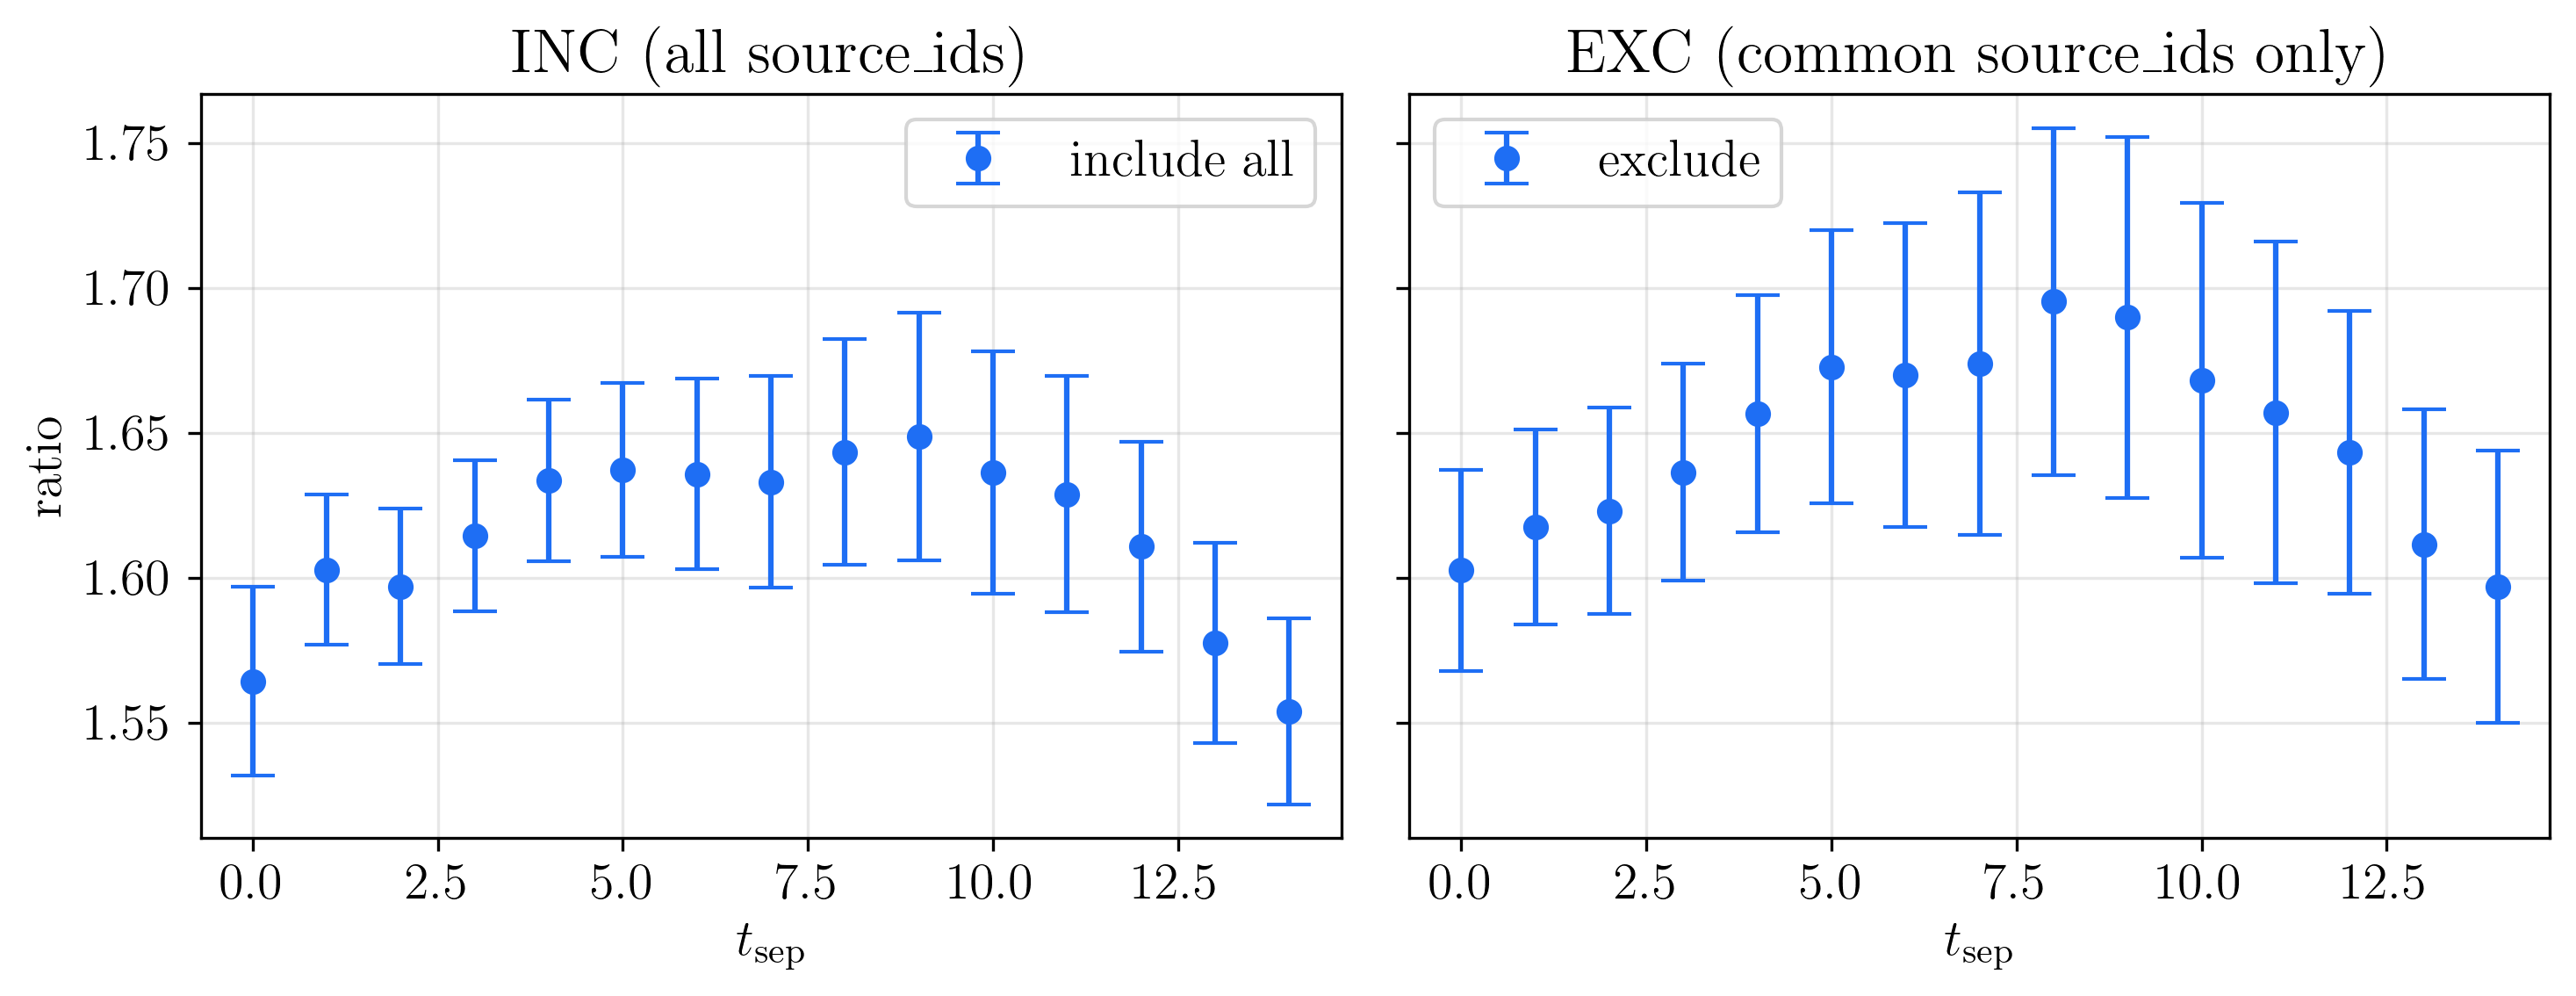

In [62]:
# x-axis: tsep index (or replace by physical tsep values if you have them)
tsep = np.arange(y_inc_est.size)

fig, axs = plt.subplots(
    nrows=1, ncols=2,
    figsize=(10, 4),
    sharey=True
)

# ---------- LEFT: INCLUDE ALL ----------
axs[0].errorbar(
    tsep,
    y_inc_est,
    yerr=y_inc_err,
    fmt='o',
    capsize=6,
    label='include all'
)
axs[0].set_title("INC (all source_ids)")
axs[0].set_xlabel(r"$t_{\mathrm{sep}}$")
axs[0].set_ylabel("ratio")
axs[0].grid(alpha=0.3)
axs[0].legend()

# ---------- RIGHT: EXCLUDE ----------
axs[1].errorbar(
    tsep,
    y_exc_est,
    yerr=y_exc_err,
    fmt='o',
    capsize=6,
    label='exclude'
)
axs[1].set_title("EXC (common source_ids only)")
axs[1].set_xlabel(r"$t_{\mathrm{sep}}$")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()